# Function 5

The function is described by 4 input features, each of which is normalised to lie between 0 and 1. The optimisation goal is to maximise the output value. The function describes the yield of a chemical process in a factory. The four input features are the chemical inputs. Based on domain knowledge of the process, the function is expected to be unimodal with a single peak. The initial data set consists of 20 data points.

## Summary

A promising region exists where `x2` and `x3` are close to 1.0, i.e. close the upper boundary. There is a suspicion that the output is relatively insensitive to `x0`, although there are not enough data points to claim this with certainty.

Two models have proven effective in finding what is believed to be the global maximum. The first model was Bayesian Optimisation with a Gaussian Process surrogate model with Radial Basis Function (RBF) kernel. As only one peak was expected, an early policy of exploitation was adopted, and therefore the Probability of Improvement (PI) acquisition function was used to assess points in a grid search. At later stages, a random forests ensemble model comprised of 500 trees with a maximum tree depth of 5 and a minimum of 2 samples per node was also effective and found the point with the highest output. It was introduced to provide an alternative that was less sensitive to kernel assumptions. The variance across the trees provided uncertainty estimates that allowed for the use of Upper Confidence Bound (UCB), PI and Expected Improvement (EI) acquisition functions for evaluation. No other promising regions were found.

## Week 1 - Initial exploitation

In [11]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid

seed_input = "function 5"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [17]:
X, y = get_current_weeks_points(function_id=5, week=1)

print(f"Mean = {y.mean()}")
print(f"Standard deviation = {y.std()}")

print(f"Minimum = {y.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(y, quantile)}")
print(f"Maximum = {y.max()}\n")

max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]
mask = np.ones(len(X), dtype=bool)
mask[max_idx] = False
print(f"Minimum distance between best point and nearest neighbour = {np.min(np.linalg.norm(X[mask] - x_best, axis=1))}")

Mean = 151.27187567901282
Standard deviation = 245.57598070645597
Minimum = 0.1129397953712203
25.0% quantile = 22.89266113509992
50.0% quantile = 63.948431302362096
75.0% quantile = 140.4848092138821
Maximum = 1088.8596181962705

Minimum distance between best point and nearest neighbour = 0.2602517864080758


Initial exploratory data analysis indicates that many of the initial data points have relatively low outputs. There appears to be a large gap between the 75% quantile and maximum, implying that there may be a very small number of points that yield a high output. While both the mean and median are low, the mean is almost a factor of 3 greater than the median, implying that there are some high output outliers influencing it. This is confirmed when we look at the 2D plots:

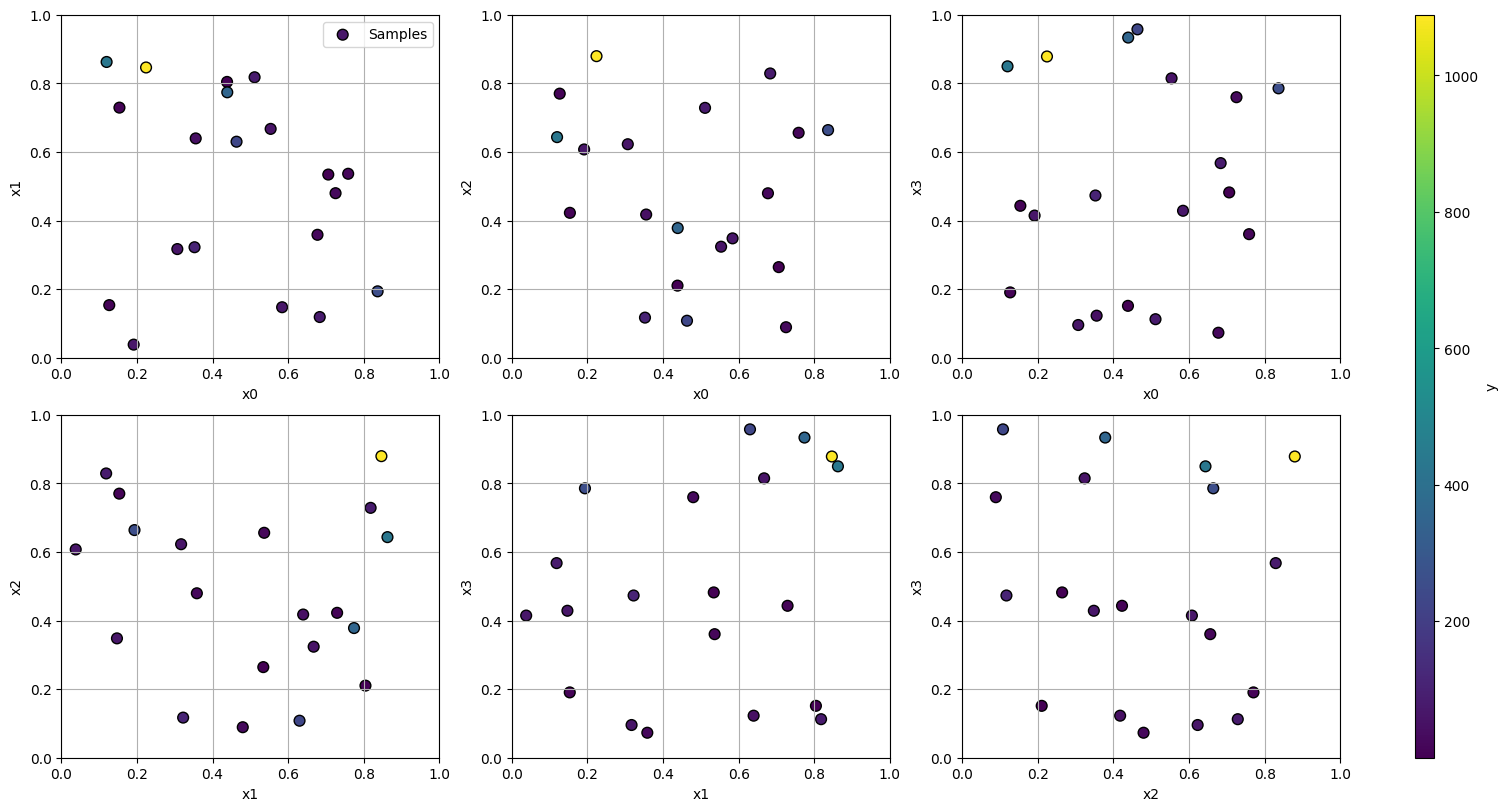

In [4]:
fig, axs = plot_2d_array(X, y)

One point has a significantly greater output than the others. As we are expecting a single global peak, rather than explore we can exploit the region around this point. Once we are satisfied that we are close to the maximum, we can challenge the assumption of there being a single global maximum and explore other regions.

We fit a Gaussian Process surrogate model to the data and perform a grid search to find candidate points to query. A relatively low grid resolution is used for computational reasons. As we are exploiting the region around the best point, the candidate points are assessed with the Probability of Improvement (PI) acquisition function. Given that only one peak is expected and the point with the highest output is not close to other points, we assume that the peak is smooth. Therefore, we use a Radial Basis Function (RBF) kernel with length scales fixed at 0.25. Fixing the length scales at this stage is reasonable to avoid overfitting:

In [18]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.25, 0.25, 0.25, 0.25], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Use Probability of Improvement (PI) acquisition function for exploitation
acq = acquisition.prob_improv(y_mean, y_std, y_max)
max_idx = np.argmax(acq)
x_next = X_pred[max_idx]
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

Proposed point using Probability of Improvement (PI) acquisition function = [0.25 0.85 0.9  0.9 ]
Distance between proposed point and best point = 0.039510355247790396


The proposed point is very close to the best point. This will give us an idea of how rapidly the output changes in this region.

## Week 2 - Converging toward a maximum

In [23]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 5"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [24]:
X, y = get_current_weeks_points(function_id=5, week=2)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.25 0.85 0.9  0.9 ] yields 1321.7618588223995


Last week's query outputs a new maximum. This implies that we can, through this iterative process, gradually converge towards the maximum in this region.

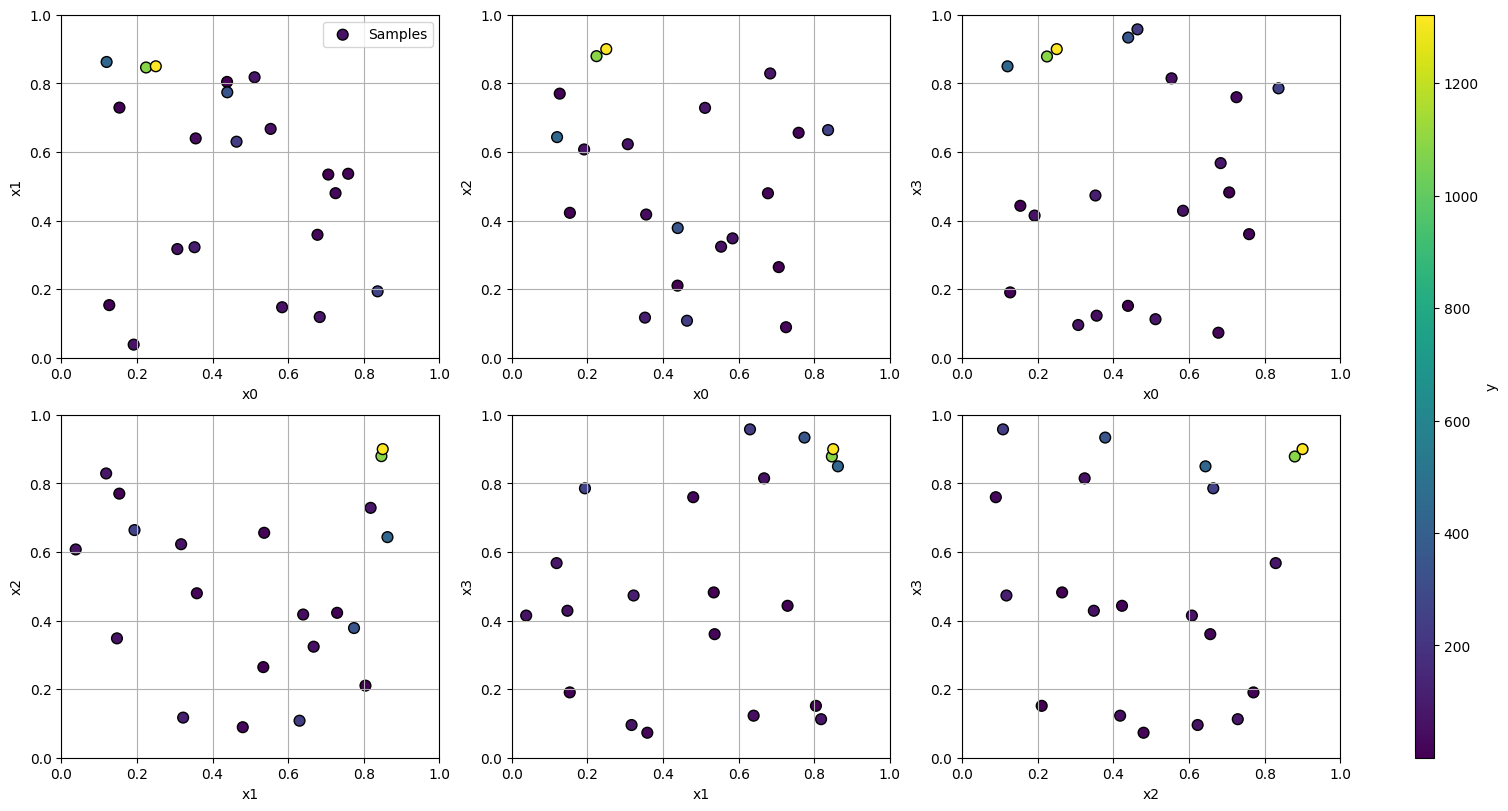

In [25]:
fig, axs = plot_2d_array(X, y)

From the plots above, there seems to be a small promising region. The grid resolution is rather coarse for a 4D space, which limits our ability to find the peak. We can, through a recursive process, identify a promising candidate on the grid that maximises the Probability of Improvement (PI) acquisition function, zoom in on this point and draw another grid around it at a higher resolution. We can repeat this process until we reach a resolution equivalent to 1e-6 decimal places, as this is the maximum precision of inputs we can submit in our queries. For now, we stick with a Gaussian Process surrogate model with fixed length scales of 0.25 to maintain model stability:

In [28]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.25, 0.25, 0.25, 0.25], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Construct initial grid to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Find best point
max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]

# Perform grid search using Probability of Improvement acquisition function
x_next = grid_search(
    model,
    acq_func=acquisition.prob_improv,
    y_max=y_max,
    n_dimensions=4,
    grd_res=grd_res,
)
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

Proposed point using Probability of Improvement acquisition function = [0.28655922 0.83655922 0.93655922 0.93655922]
Distance between proposed point and best point = 0.06473317563229389


The proposed point is close to the best point, but that is expected given that we are maximising the PI acquisition function.

When I initially conducted the analysis, I did not set the random state, and therefore the optimiser used different random initialisations when tuning the model's hyperparameters. As a result, I ended up querying the slightly different point of (0.285594, 0.835584, 0.92592, 0.93208). This is a minor discrepancy and should have no effect on the general upward trend on the output.

## Week 3 - Continuing to exploit the best point

In [29]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 5"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [30]:
X, y = get_current_weeks_points(function_id=5, week=3)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.285594 0.835584 0.92592  0.93208 ] yields 1613.4630825046502


With every query the maximum output continues to increase. The framework is working well, and there is no reason for a change in strategy:

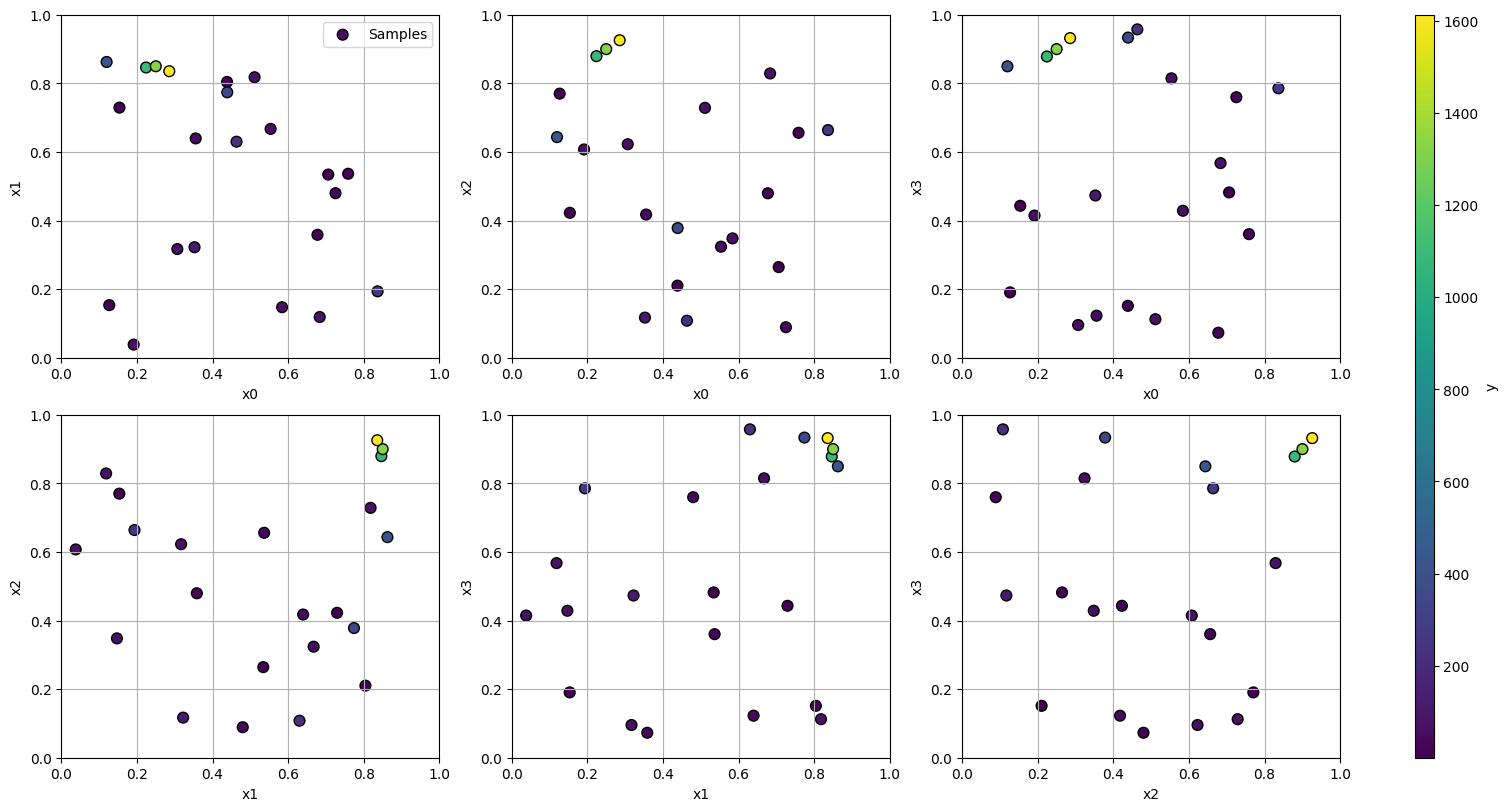

In [31]:
fig, axs = plot_2d_array(X, y)

In [32]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.25, 0.25, 0.25, 0.25], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Construct initial grid to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Find best point
max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]

# Perform grid search using Probability of Improvement acquisition function
x_next = grid_search(
    model,
    acq_func=acquisition.prob_improv,
    y_max=y_max,
    n_dimensions=4,
    grd_res=grd_res,
)
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

Proposed point using Probability of Improvement acquisition function = [0.34596234 0.79596234 0.94596234 0.99596234]
Distance between proposed point and best point = 0.09847264573016024


With every iteration, the distance between the proposed and best points is gradually increasing. This indicates that the optimum has not been reached.

As with last week's analysis, I did not set the random state and therefore queried the point (0.31751, 0.803754, 0.947437, 0.962877). The proposed point above and the queried point lie in the same region, and the logic behind their selections is the same.

## Week 4 - Reaching the `x3` boundary

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 5"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=5, week=4)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.31751  0.803754 0.947437 0.962877] yields 1849.295315062432


Last week's query yields another increase in output. This provides us with a strong incentive to continue with our framework:

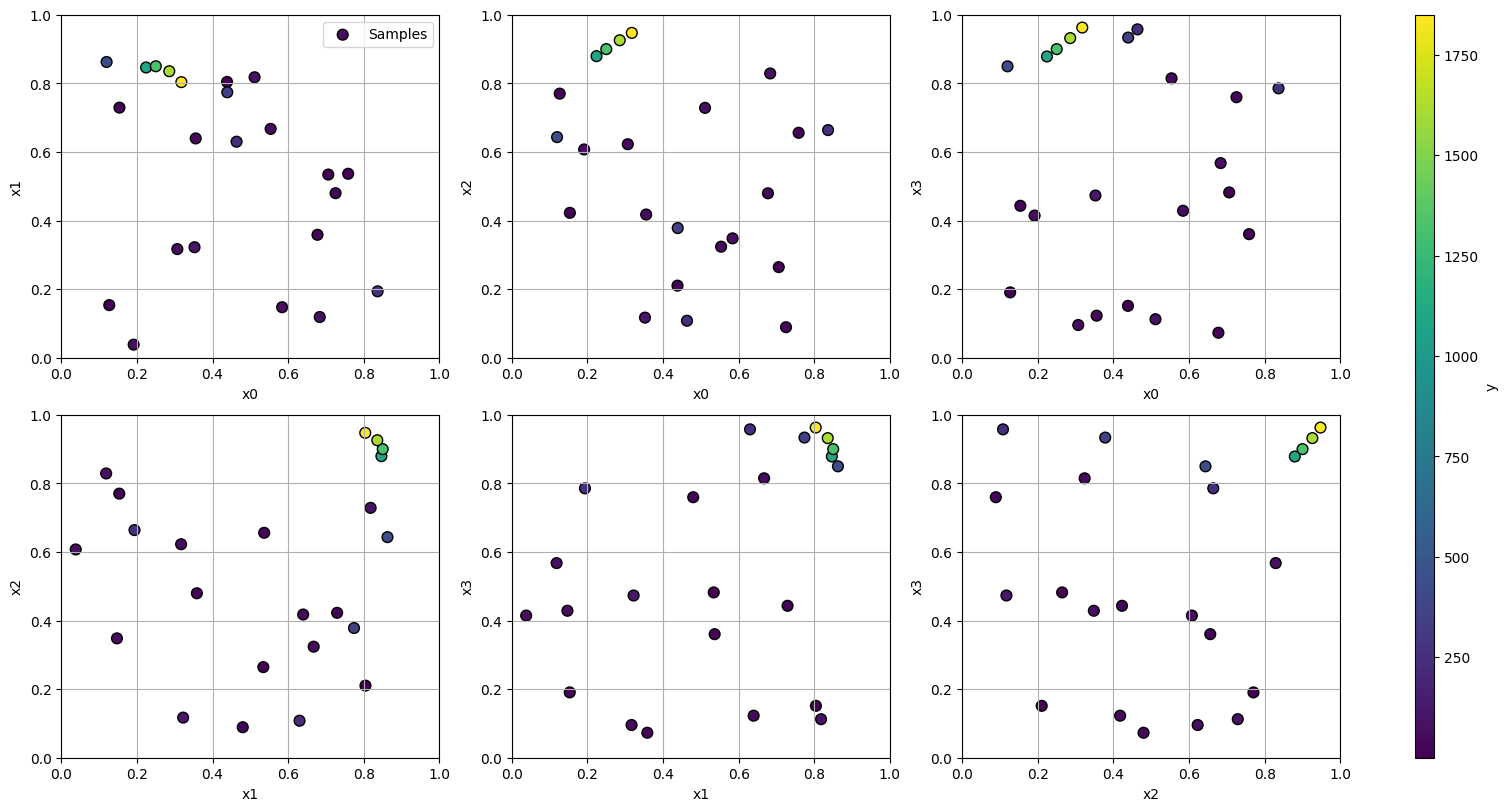

In [3]:
fig, axs = plot_2d_array(X, y)

In [4]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.25, 0.25, 0.25, 0.25], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Construct initial grid to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Find best point
max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]

# Perform grid search using Probability of Improvement acquisition function
x_next = grid_search(
    model,
    acq_func=acquisition.prob_improv,
    y_max=y_max,
    n_dimensions=4,
    grd_res=grd_res,
)
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

Proposed point using Probability of Improvement acquisition function = [0.36030922 0.76030922 0.96030922 0.99993422]
Distance between proposed point and best point = 0.07251312722882601


The Euclidean distance between the proposed and best points is smaller than it was last week. This may be because the proposed point lies very close to the `x3` upper boundary. It is possible that had the grid not been clipped here, the model would propose a point outside of the domain. Another possibility is that the model simply believes that we are converging on the maximum.

As noted previously, the query that was submitted this week differs slightly from the proposed point above due to the random initialisation of the model. The point (0.353073, 0.749582, 0.970293, 0.999) was submitted for this week's query. This point lies in the same region as the proposed point, and has been obtained through the same strategy of exploitation.

## Week 5 - Support Vector Machine guided boundary probing

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array, plot_confusion_matrix
from bbo.random import create_rng_seed
from bbo.support_vector_machines import get_svm_classifier
from bbo.utils import grid_search

seed_input = "function 5"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=5, week=5)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.353073 0.749582 0.970293 0.999   ] yields 2127.805066389777


Last week's query yields another increase in output. We are approaching the `x2` and `x3` upper boundaries, or in other words the limits of the domain in these dimensions.

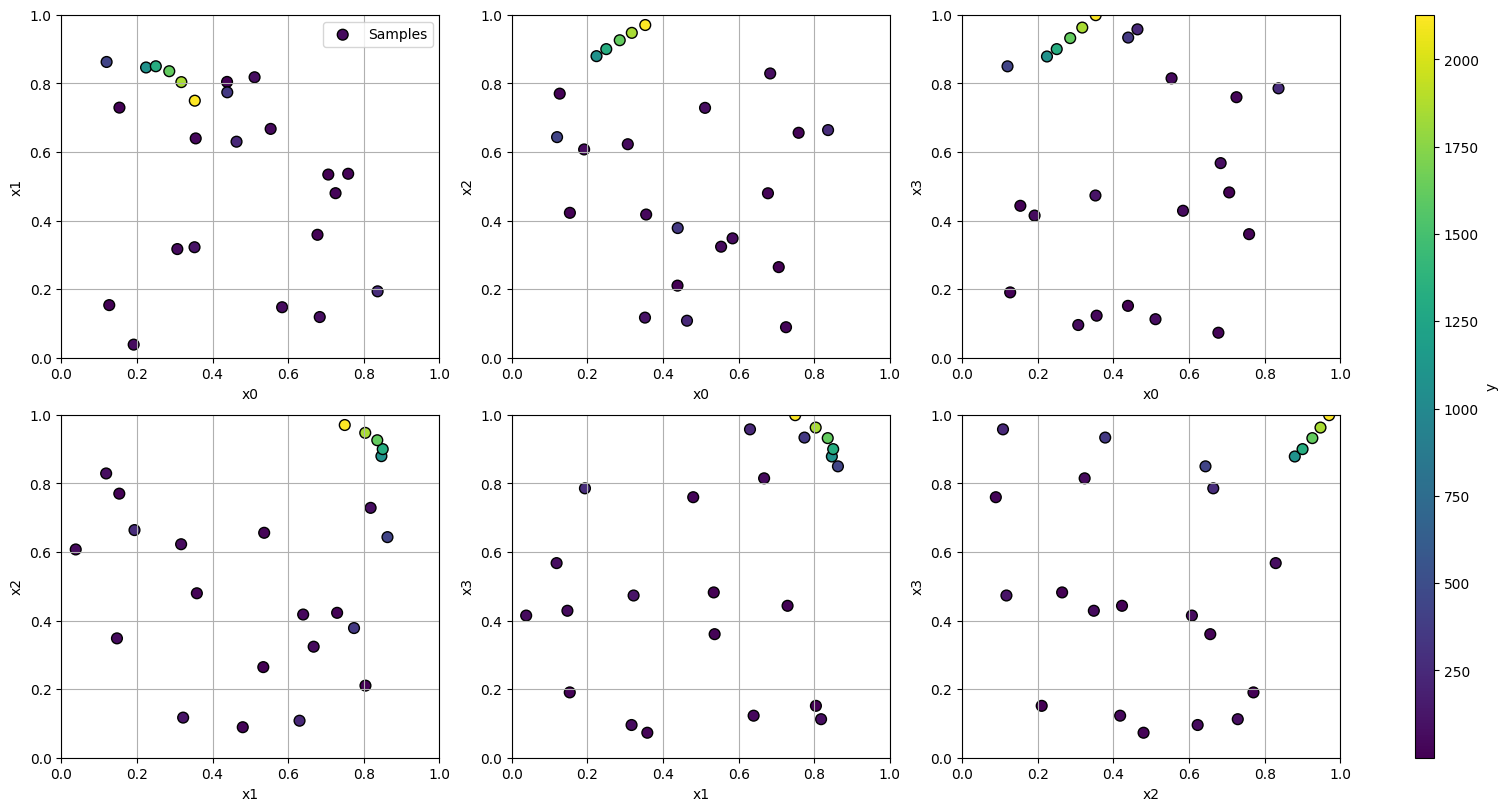

In [3]:
fig, axs = plot_2d_array(X, y)

From the plots above, there appears to be a very promising region at around (0.35, 0.75, 1.0, 1.0). So far, we have assumed that all feature contribute equally to the output. However, this is not necessarily the case. We can allow the length scales to vary, and see what the Gaussian Process surrogate model and Probability of Improvement (PI) acquisition function suggest as the next point to query:

In [4]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=n_dimensions, seed_input=seed_input, length_scale_bounds=(1e-3, 1000)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Find best point
max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]

# Perform grid search using Probability of Improvement acquisition function
x_next = grid_search(
    model,
    acq_func=acquisition.prob_improv,
    y_max=y_max,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
)
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Length scales: [1.00000000e+03 3.16656580e+01 6.68734995e-01 1.02280643e-01]
Proposed point using Probability of Improvement acquisition function = [0.35 0.75 1.   1.  ]
Distance between proposed point and best point = 0.029885178634232762


The Gaussian Process surrogate model has been fit to the global data. Now that the length scales are free, that of `x0` hits the upper boundary. This implies that the model believes the output to be insensitive to changes in `x0`. Even the length scale for `x1` is quite high at 31.7, implying that moving in this dimension may not have much of an effect on the output.

In contrast, the model indicates that the output is sensitive to changes in `x2` and `x3`, as reflected by their much lower length scales. Interestingly, the proposed point suggested lines up with our estimate of the position of the promising region above.

The distance between the proposed point and best point is quite small. We may have reached the point of diminishing returns. Additionally, the proposed point does not directly test the model's hypothesis that the output is insensitive to changes in `x0` and `x1`. From the 2D plots, there appears to be a promising region, which we should take a look at in more detail.

We can try to define this region using a Support Vector Machines (SVM) classification model, where we define the boundary as the mean output. Any points with outputs above the mean are defined as high, and those below the mean are defined as low:

Mean output = 414.0734515149798
Number of support vectors = 11


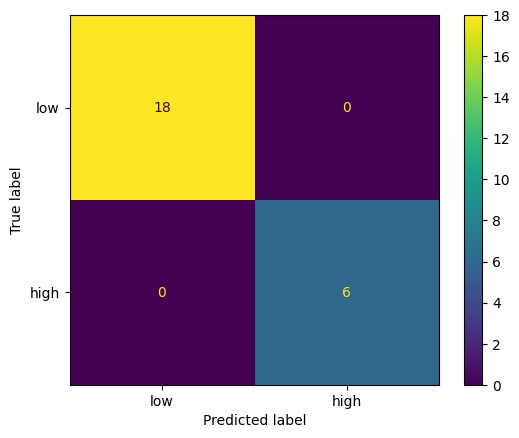

In [8]:
# Create Support Vector Machines (SVM) classifier and fit to data
# Use mean output as boundary between high and low outputs
# Use Radial Basis Function kernel
clf, above_mean_y = get_svm_classifier(X, y)
print(f"Mean output = {y.mean()}")
print(f"Number of support vectors = {len(clf.support_vectors_)}")

# Plot confusion matrix
cmd = plot_confusion_matrix(X, clf, above_mean_y, labels=["low", "high"])
cmd.plot()

Looking at the confusion matrix, the SVM classification model does a good job of separating high and low data points. The mean output is high enough that there does not appear to be much contamination from data points with a low output. The number of support vectors is just under half the number of data points, which is reasonable.

We can arrange the support vectors by descending influence and see how far they lie from the decision boundary:

In [20]:
# List support vectors and distances to boundary in order of influence
influence = np.abs(clf.dual_coef_[0])
ordered_idx = np.argsort(-influence)

for idx in ordered_idx:
    sv = clf.support_vectors_[idx]
    influence_val = clf.dual_coef_[0][idx]
    decision_function = clf.decision_function([sv])[0]
    print(f"Support vector = {sv},\tinfluence = {influence_val},\tDecision function = {decision_function}")

Support vector = [0.43893338 0.77409176 0.37816709 0.93369621],	influence = -1.0,	Decision function = -0.8387175366145376
Support vector = [0.11987923 0.86254031 0.64333133 0.84980383],	influence = 1.0,	Decision function = 0.4687286999877177
Support vector = [0.353073 0.749582 0.970293 0.999   ],	influence = 1.0,	Decision function = 0.9359639398666447
Support vector = [0.15378571 0.72938169 0.42259844 0.44307417],	influence = -0.6082619437590978,	Decision function = -0.9998523720969292
Support vector = [0.22418902 0.84648049 0.87948418 0.87851568],	influence = 0.5609987396375655,	Decision function = 0.9997304515458062
Support vector = [0.51114177 0.817957   0.72871042 0.11235362],	influence = -0.2458251528651977,	Decision function = -1.0000341884960897
Support vector = [0.83647799 0.19360965 0.6638927  0.78564888],	influence = -0.2190642945424899,	Decision function = -1.0003708612477509
Support vector = [0.68343225 0.11866264 0.82904591 0.56757661],	influence = -0.18821168800459814,	De

There are three support vectors that have a considerably large influence on the position of the decision boundary. Of these, the point at (0.11987923, 0.86254031, 0.64333133, 0.84980383) lies closest to the decision boundary. Looking at the 2D plots above, of all the data points in the high region, it has the lowest output. The Gaussian Process surrogate model believes that the output is insensitive to changes in the `x0` and `x1` dimensions. To investigate this region, we can hold these two dimensions constant and move further into the region in the `x2` and `x3` dimensions. We can calculate the gradient with respect to `x2` and `x3` and take a step in the steepest direction:

In [21]:
# Calculate gradient and normalise to find direction vector
svs = clf.support_vectors_[ordered_idx]
sv_selected = svs[1]
grad = np.zeros_like(sv_selected)
f0 = clf.decision_function([sv_selected])[0]  # distance to boundary
eps = 1e-4  # step size for differential

for i in [2, 3]:  # features x2 and x3 are free
    x_eps = sv_selected.copy()
    x_eps[i] += eps
    x_eps[i] = np.clip(x_eps[i], 0.0, 1.0)  # ensure feature lies within bounds

    fi = clf.decision_function([x_eps])[0]
    grad[i] = (fi - f0) / eps

direction = grad / np.linalg.norm(grad)

x_next = sv_selected + 0.03 * direction
print(f"Proposed point to explore high region near boundary = {x_next}")
print(f"Distance between proposed point and support vector = {np.linalg.norm(sv_selected - x_next)}")

Proposed point to explore high region near boundary = [0.11987923 0.86254031 0.67120146 0.86090589]
Distance between proposed point and support vector = 0.029999999999999978


In order to calculate the gradient of the decision function, we need to take a small step ($\epsilon$ = 0.0001) in each dimension of interest (i.e. `x2` and `x3`) and measure the difference in decision function values. We then normalise the gradient to give us a unit vector in the direction of the steepest increase in the decision function. We then take a step size of 0.03 (3% of the full range) in the steepest direction. The small step size is to ensure we stay in the same neighbourhood as the support vector, allowing us to explore near the boundary.

## Week 6 - Looking for other promising regions

In [1]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.clustering import get_dbscan_labels
from bbo.data import get_current_weeks_points
from bbo.plotting import (
    plot_2d_array,
    plot_confusion_matrix,
    plot_nearest_neighbour_distance,
)
from bbo.random import get_candidates_uniform
from bbo.support_vector_machines import get_svm_classifier
from bbo.utils import grid_search

seed_input = "function 5"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=5, week=6)

print(f"Last week's query {X[-1]} yields {y[-1]}")

# Find nearest neighbour, which is support vctor from last week
distances = np.linalg.norm(X[:-1] - X[-1], axis=1)
min_idx = np.argmin(distances)
print(f"Support vector {X[min_idx]} has an output of {y[min_idx]}")

Last week's query [0.119879 0.86254  0.671201 0.860906] yields 499.4168921210305
Support vector [0.11987923 0.86254031 0.64333133 0.84980383] has an output of 431.6127567592104


The output from last week's query is higher than that of the support vector. We moved along the gradient of the decision function, away from the boundary in `x2` and `x3`, resulting in a higher output. This confirms last week's Gaussian Process surrogate model's belief that the output is sensitive to changes in `x2` and `x3`. Although we held `x0` and `x1` constant (i.e. at the same value as the support vector), it does not necessarily indicate that the output is insensitive to changes in `x0` and `x1`.

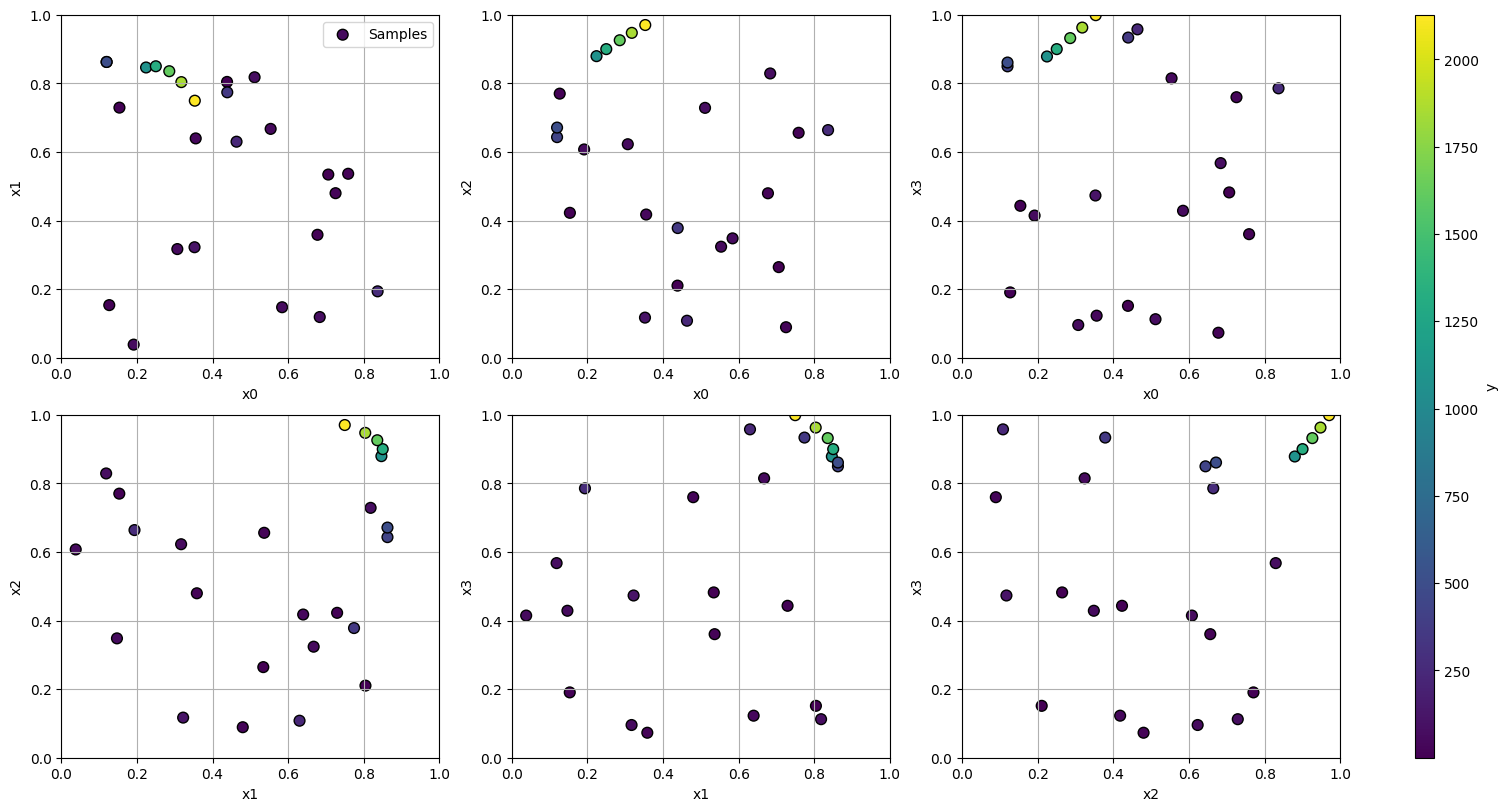

In [3]:
fig, axs = plot_2d_array(X, y)

Last week's query indicates that there is a region of relatively high output, and that the decision boundary is in the correct place. However, we are not near the optimum value because the mean is significantly less than our highest output. From the plots above, there appear to be 5 points out of a total of 25 that are in the promising region. Using the 80% quantile as the decision boundary would be more representative of the high region:

Mean output = 417.48718913922187
80% quantile = 617.3054373360802
Number of support vectors = 17


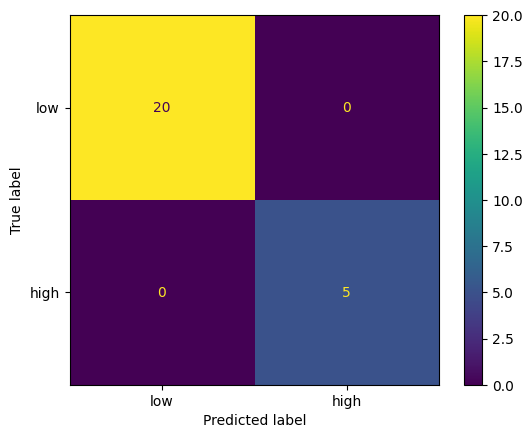

In [4]:
# Create Support Vector Machines (SVM) classifier and fit to data
# Use 80% quantile as boundary between high and low outputs
# Use Radial Basis Function kernel
quant_80_pc = np.quantile(y, 0.8)
print(f"Mean output = {y.mean()}")
print(f"80% quantile = {quant_80_pc}")
clf, above_80_pc_quant = get_svm_classifier(X, y, threshold=quant_80_pc)
print(f"Number of support vectors = {len(clf.support_vectors_)}")

# Plot confusion matrix
cmd = plot_confusion_matrix(X, clf, above_80_pc_quant, labels=["low", "high"])
cmd.plot()

If we consider the range of output values, the 80% quantile is not that much greater than the mean. Additionally, the number of support vectors has increased to 17. This implies that the boundary between high and low regions is complicated, and this most likely is a result of a lack of data.

We expect that this promising region that we have identified contains the global maximum. However, we can dedicate at least one query to testing this assumption. As we have a limited number of queries, and we would like to exploit the identified promising region and investigate whether `x0` and `x1` are important, we need to be efficient if we are going to explore other parts of the domain. Rather than use a grid search, we can generate random sets of candidate points across the domain that we can evaluate using a Guassian Process surrogate model and Upper Confidence Bound (UCB) acquisition function. To encourage exploration, we can apply a penalty to any points that lie close to the best point. The penalty decays as a function of distance from the best point.

We can collect the best 5 candidates from each set/iteration and using the Density-Based Spatial Clustering of Applications with Noise (DBSCAN) algorithm, divide them into clusters. To find a suitable value for the maximum distance between two samples in the same neighbourhood, we can plot the distances of each point to its kth nearest neighbour and estimate the position where there is a significant change in this distance. We can define a dense region as one where a point has 5 neighbours:

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Length scales: [1.00000000e+03 1.00000000e+03 3.42192200e-01 1.09382343e-01]


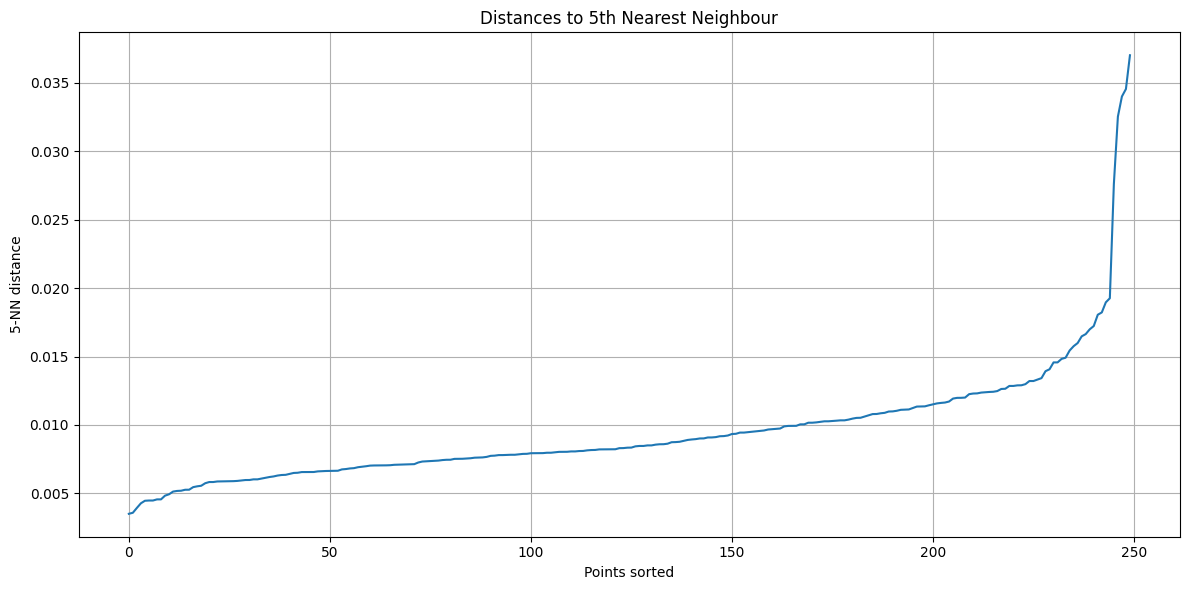

In [5]:
# Fit Gaussian Process surrogate model with RBF kernel on known data
model = get_reg_model(
    n_dimensions=n_dimensions, seed_input=seed_input, length_scale_bounds=(1e-3, 1000)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Find best point and predicted value there
max_idx = np.argmax(y)
x_best = X[max_idx]
pred_x_best = model.predict(x_best.reshape(1, -1))

n_trials = 50  # number of iterations
n_random = 10_000  # number of candidate points to generate per iteration
n_top_candidates = 5  # number of top candidate points to keep after every iteration
candidates = []
for X_rand in get_candidates_uniform(
    n_trials=n_trials,
    n_random=n_random,
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    bounds=(0.05, 0.95)
):
    y_mean, y_std = model.predict(X_rand, return_std=True)

    # Use Upper Confidence Bound (UCB) as metric
    acq = acquisition.ucb(y_mean, y_std, k=1.96)

    # Penalise acquisition around best point
    square_radius = np.sum(((X_rand - x_best) / length_scales) ** 2, axis=1)
    penalty = pred_x_best * np.exp(-0.5 * square_radius)  # penalty decays with distance from best point
    acq -= penalty

    # Keep top candidates
    top_idx = np.argsort(acq)[-n_top_candidates:]
    candidates.append(X_rand[top_idx])

candidates = np.vstack(candidates)
# Scale candidates relative to best point and length scales
X_scaled = (candidates - x_best) / length_scales

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = distances[:, -1]  # get distances to kth nearest neighbours
fig, ax = plot_nearest_neighbour_distance(distances=k_distances, k=5)

The length scales from the Gaussian Process surrogate model indicate that the model still believes that the output is relatively insensitive to changes in `x0` and `x1`.

From the plot above, we see a significant change at the position of the elbow, where the distance between a point and its 5th nearest neighbour is approximately 0.015. We can define this value to be the maximum distance between two points for them to be considered to be in each other's neighbourhood for the DBSCAN algorithm. We can then define the centre of each cluster to be the median position:

In [15]:
max_distance = 0.015
cluster_labels = get_dbscan_labels(points=X_scaled, max_distance=max_distance, min_samples=k)

labels, counts = np.unique(cluster_labels, return_counts=True)

for lbl, counts in zip(labels, counts):
    if lbl == -1:  # noise
        continue

    clusterer_points = candidates[cluster_labels == lbl]
    x_median = np.median(clusterer_points, axis=0)  # median of cluster
    mean, std = model.predict(x_median.reshape(1, -1), return_std=True)

    print(f"Cluster {lbl}, number of points = {counts}")
    print(f"Proposed point = {x_median}")
    print(f"Predicted value = {mean[0]}, standard deviation = {std[0]}")
    print(f"Distance between proposed point and best point = {np.linalg.norm(x_median - x_best)}")
    print(f"Distance between proposed point and nearest neighbour = {np.min(np.linalg.norm(X - x_median, axis=1))}\n")

Cluster 0, number of points = 197
Proposed point = [0.48577678 0.46634387 0.0560008  0.31034667]
Predicted value = 292.41498405619154, standard deviation = 437.8411913169447
Distance between proposed point and best point = 1.1865950304333563
Distance between proposed point and nearest neighbour = 0.2622548868745677

Cluster 1, number of points = 40
Proposed point = [0.46529404 0.50655613 0.05231727 0.62687016]
Predicted value = 311.285109685203, standard deviation = 424.56411846469894
Distance between proposed point and best point = 1.0260678309649238
Distance between proposed point and nearest neighbour = 0.27303737615457496

Cluster 2, number of points = 7
Proposed point = [0.48156005 0.69546951 0.05151226 0.32799835]
Predicted value = 315.73201954590775, standard deviation = 421.0721303858179
Distance between proposed point and best point = 1.146227876338463
Distance between proposed point and nearest neighbour = 0.26483984374984443



The algorithm has identified three clusters. Although the positional median provides a good representation of each cluster, it does not maximise the acquisition function within the region. Therefore, it simply provides a promising point in that cluster to query, that may lead to the discovery of a promsing region to exploit. The predicted output of the median points in each case have large errors, implying that these regions are underexplored and may contain high value points. The distances between the medians and the best point are relatively large, implying that they all lie in different region. They also lie approximately the same distance from their nearest neighbours. Therefore, we should choose the largest cluster (i.e. cluster 0), as this has been identified as promising across multiple iterations.

A different random seed was used to generate the candidate points in the original analysis, resulting in different clusters with different median points. The point (0.49403763, 0.48920023, 0.05, 0.31145593) was submitted as a query, which is in the same cluster as the largest one above, and therefore is representative of the promising region.

## Week 7

In [17]:
import numpy as np

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array

seed_input = "function 5"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [18]:
X, y = get_current_weeks_points(function_id=5, week=7)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.494038 0.4892   0.05     0.311456] yields 82.58398332765519
